# 03 - Baseline Model

Week 4 deliverable: train a baseline Linear Regression model and evaluate it with R² on the test set.

Split used:
- **Train:** November 2024 through November 2025
- **Validation:** December 2025 through February 2026
- **Test:** March 2026 through May 2026

In [37]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [38]:
DATA_FILE = Path("data/week4_cleaned_model_data.csv")
RESULTS_FILE = Path("data/week4_baseline_linear_regression_results.csv")
SPLIT_RESULTS_FILE = Path("data/week4_baseline_split_comparison_results.csv")
CORRELATION_FILE = Path("data/week4_feature_correlation_matrix.csv")

df = pd.read_csv(DATA_FILE, low_memory=False)
df.shape


(202624, 28)

## Feature / Target Setup

Use the model-ready features from preprocessing. Metadata columns and target columns are excluded from `X`.

In [39]:
target = "ClosePrice"
metadata_cols = ["ListingId", "CloseDate", "close_month", "split"]
target_cols = ["ClosePrice", "LogClosePrice"]
feature_cols = [col for col in df.columns if col not in metadata_cols + target_cols]

print(f"Feature count: {len(feature_cols)}")
feature_cols


Feature count: 22


['Latitude_scaled',
 'Longitude_scaled',
 'LivingArea_scaled',
 'BedroomsTotal_scaled',
 'BathroomsTotalInteger_scaled',
 'YearBuilt_scaled',
 'Stories_scaled',
 'GarageSpaces_scaled',
 'ParkingTotal_scaled',
 'AssociationFee_scaled',
 'LotSizeSquareFeet_scaled',
 'LotSizeAcres_scaled',
 'LotSizeArea_scaled',
 'HomeAge_scaled',
 'ViewYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'City_freq',
 'PostalCode_freq',
 'CountyOrParish_freq',
 'MLSAreaMajor_freq',
 'HighSchoolDistrict_freq']

## Train / Validation / Test Split

In [40]:
train = df[df["split"] == "train"].copy()
validation = df[df["split"] == "validation"].copy()
test = df[df["split"] == "test"].copy()

split_summary = df.groupby("split")["close_month"].agg(["min", "max", "nunique", "count"])
split_summary


,min,max,nunique,count
split,,,,
test,2026-03,2026-05,3,35193
train,2024-11,2025-11,13,140956
validation,2025-12,2026-02,3,26475


## Train Baseline Linear Regression

In [41]:
X_train = train[feature_cols]
y_train = train[target]

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_model


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[ -73289.92, -78073.04, 778457.61,...,-196886.86,-110281.59, 469003.68]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['Latitude_scaled','Longitude_scaled','LivingArea_scaled',..., 'CountyOrParish_freq','MLSAreaMajor_freq','HighSchoolDistrict_freq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.464e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(21)


## Evaluate Baseline

In [42]:
def evaluate_split(model, split_name: str, split_df: pd.DataFrame) -> dict:
    X = split_df[feature_cols]
    y = split_df[target]
    predictions = model.predict(X)

    return {
        "model": "LinearRegression",
        "target": target,
        "split": split_name,
        "rows": len(split_df),
        "r2_close_price": r2_score(y, predictions),
        "mae_close_price": mean_absolute_error(y, predictions),
        "rmse_close_price": float(np.sqrt(mean_squared_error(y, predictions))),
    }


baseline_results = pd.DataFrame([
    evaluate_split(baseline_model, "train", train),
    evaluate_split(baseline_model, "validation", validation),
    evaluate_split(baseline_model, "test", test),
])

baseline_results


,model,target,split,rows,r2_close_price,mae_close_price,rmse_close_price
0,LinearRegression,ClosePrice,train,140956,0.499931,479200.484688,849709.902382
1,LinearRegression,ClosePrice,validation,26475,0.499136,478109.919459,880027.974047
2,LinearRegression,ClosePrice,test,35193,0.507638,492991.207051,879510.390343


## Record Baseline Results

In [43]:
baseline_results.to_csv(RESULTS_FILE, index=False)

test_r2 = baseline_results.loc[baseline_results["split"] == "test", "r2_close_price"].iloc[0]

print(f"Wrote {RESULTS_FILE}")
print(f"Baseline Linear Regression test R²: {test_r2:.4f}")


Wrote data/week4_baseline_linear_regression_results.csv
Baseline Linear Regression test R²: 0.5076


## Feature Correlation Matrix

For regression, this is the useful equivalent of the requested variable “confusion matrix”: it shows how strongly each model input moves with every other input.


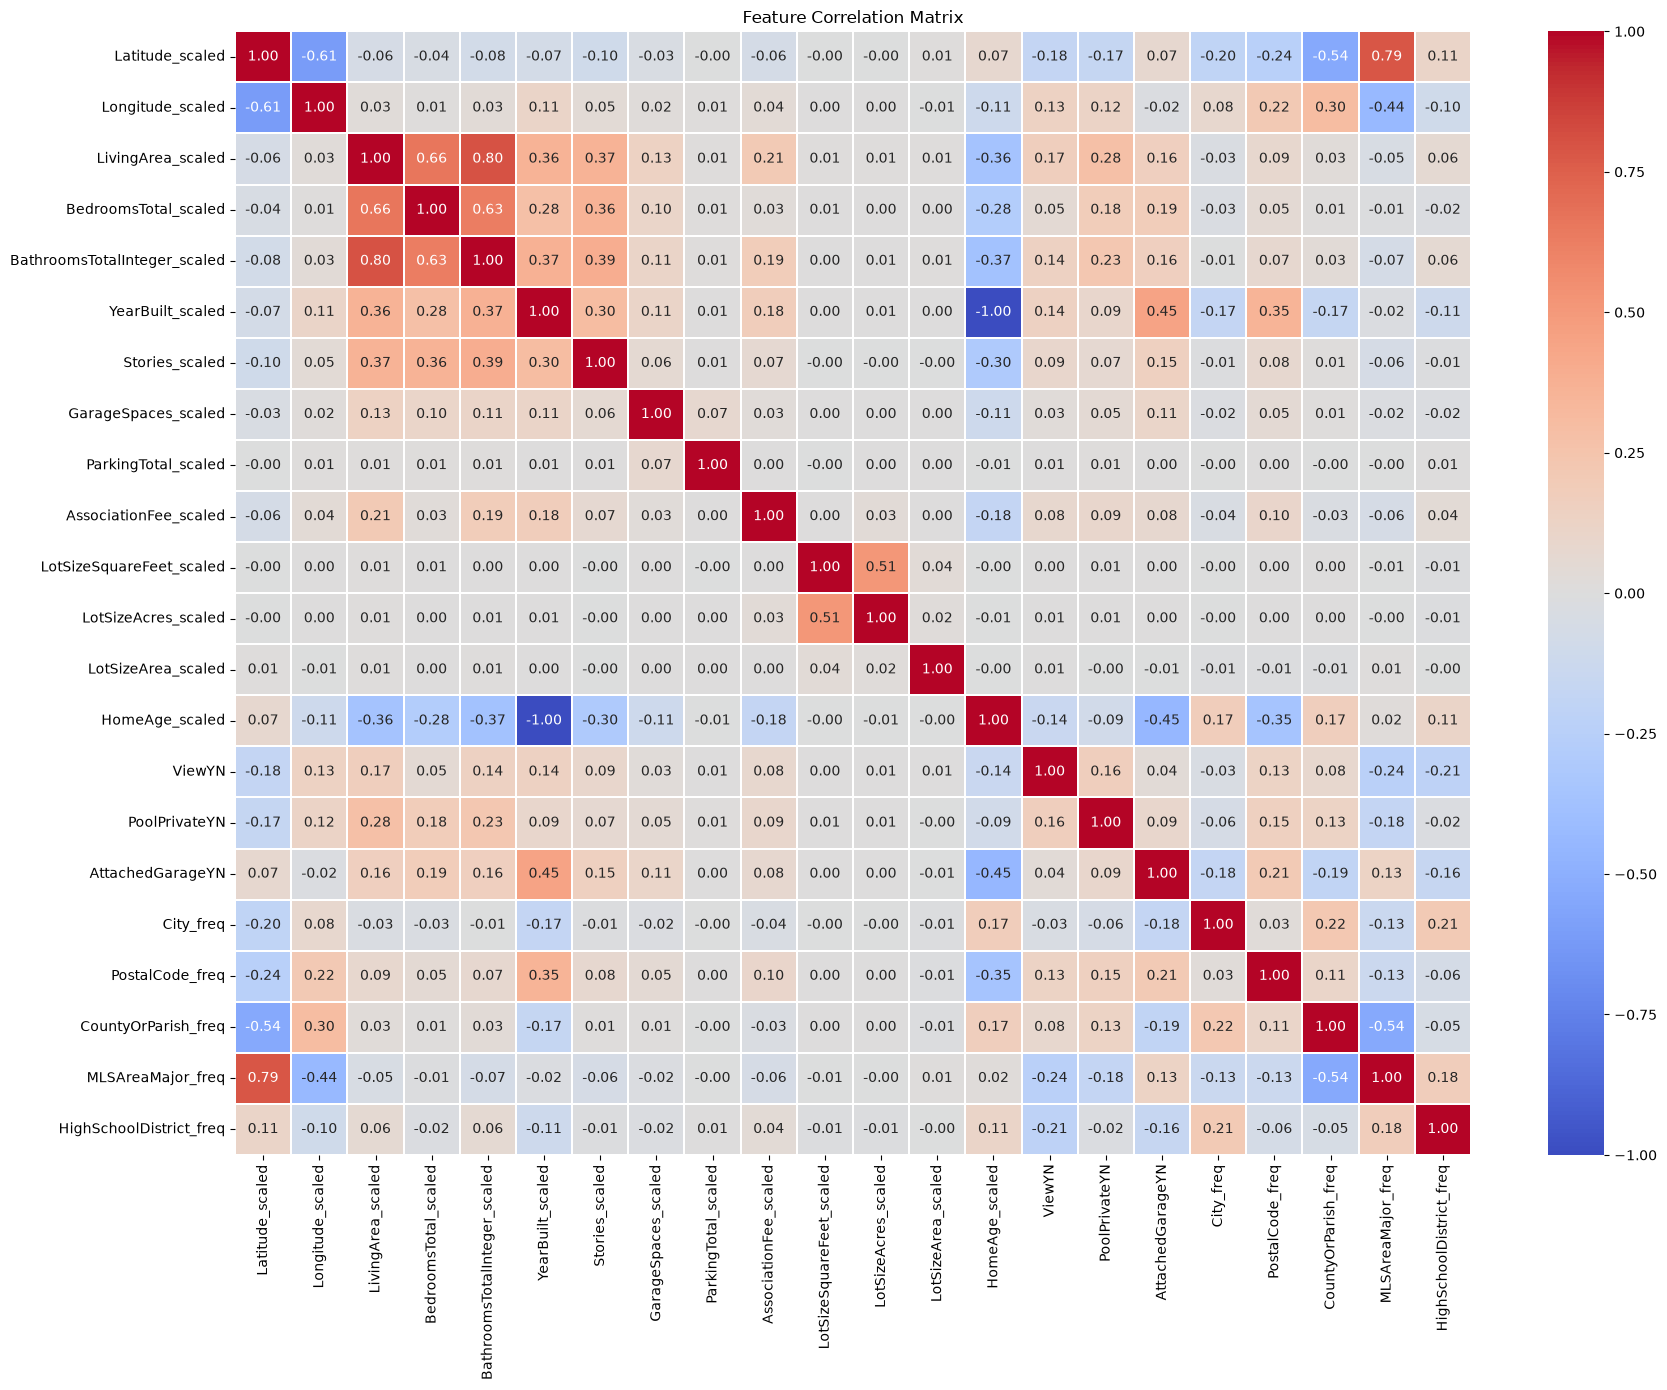

,Latitude_scaled,Longitude_scaled,LivingArea_scaled,BedroomsTotal_scaled,BathroomsTotalInteger_scaled,YearBuilt_scaled,Stories_scaled,GarageSpaces_scaled,ParkingTotal_scaled,AssociationFee_scaled,...,LotSizeArea_scaled,HomeAge_scaled,ViewYN,PoolPrivateYN,AttachedGarageYN,City_freq,PostalCode_freq,CountyOrParish_freq,MLSAreaMajor_freq,HighSchoolDistrict_freq
Latitude_scaled,1.000000,-0.613695,-0.061041,-0.044397,-0.078957,-0.073247,-0.099553,-0.031672,-0.003698,-0.063253,...,0.012583,0.073247,-0.176978,-0.167846,0.073313,-0.197656,-0.242322,-0.537494,0.785703,0.112115
Longitude_scaled,-0.613695,1.000000,0.025681,0.011827,0.032873,0.111019,0.046498,0.021132,0.009942,0.043533,...,-0.007319,-0.111019,0.133445,0.119507,-0.017198,0.084969,0.217429,0.303197,-0.436218,-0.097965
LivingArea_scaled,-0.061041,0.025681,1.000000,0.658669,0.801477,0.363401,0.365356,0.134414,0.013012,0.207641,...,0.014910,-0.363401,0.168816,0.278868,0.163652,-0.028098,0.085406,0.025314,-0.045728,0.055096
BedroomsTotal_scaled,-0.044397,0.011827,0.658669,1.000000,0.628723,0.277445,0.362489,0.101604,0.008554,0.030035,...,0.002146,-0.277445,0.053069,0.180736,0.185967,-0.025264,0.053341,0.013419,-0.011955,-0.017918
BathroomsTotalInteger_scaled,-0.078957,0.032873,0.801477,0.628723,1.000000,0.373396,0.391824,0.109454,0.009230,0.185388,...,0.008264,-0.373396,0.142551,0.228230,0.160592,-0.006639,0.072813,0.033755,-0.065914,0.060934
YearBuilt_scaled,-0.073247,0.111019,0.363401,0.277445,0.373396,1.000000,0.300417,0.112277,0.006145,0.177971,...,0.001320,-1.000000,0.143398,0.093366,0.451236,-0.173459,0.353758,-0.165214,-0.023400,-0.113944
Stories_scaled,-0.099553,0.046498,0.365356,0.362489,0.391824,0.300417,1.000000,0.057319,0.005612,0.069881,...,-0.004821,-0.300417,0.086093,0.069779,0.149188,-0.008605,0.076451,0.010893,-0.056191,-0.012843
GarageSpaces_scaled,-0.031672,0.021132,0.134414,0.101604,0.109454,0.112277,0.057319,1.000000,0.070504,0.029174,...,0.001159,-0.112277,0.030258,0.054606,0.107213,-0.019705,0.054035,0.009480,-0.022314,-0.016648
ParkingTotal_scaled,-0.003698,0.009942,0.013012,0.008554,0.009230,0.006145,0.005612,0.070504,1.000000,0.002521,...,0.003220,-0.006145,0.005420,0.008986,0.002468,-0.002188,0.004583,-0.004080,-0.002364,0.006876
AssociationFee_scaled,-0.063253,0.043533,0.207641,0.030035,0.185388,0.177971,0.069881,0.029174,0.002521,1.000000,...,0.001003,-0.177971,0.084455,0.087905,0.075826,-0.037558,0.097959,-0.030292,-0.055788,0.040170


In [44]:
feature_correlation = df[feature_cols].corr()
feature_correlation.to_csv(CORRELATION_FILE)

plt.figure(figsize=(18, 14))
sns.heatmap(
    feature_correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.25,
    linecolor="white",
    annot=True,
    fmt=".2f",
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

feature_correlation


In [45]:
close_price_corr = df[feature_cols + [target]].corr()[target]
close_price_corr = close_price_corr.drop(target).sort_values(ascending=False)

mag_price_corr = close_price_corr.abs().sort_values(ascending=False)
sig_mag_price_corr_features = mag_price_corr[mag_price_corr >= 0.03].index

close_price_corr


LivingArea_scaled               0.624076
BathroomsTotalInteger_scaled    0.546774
BedroomsTotal_scaled            0.339889
AssociationFee_scaled           0.180751
PoolPrivateYN                   0.132628
HighSchoolDistrict_freq         0.129976
Stories_scaled                  0.122122
ViewYN                          0.067336
GarageSpaces_scaled             0.057132
City_freq                       0.048159
CountyOrParish_freq             0.031658
YearBuilt_scaled                0.015292
LotSizeArea_scaled              0.012431
ParkingTotal_scaled             0.005358
LotSizeAcres_scaled             0.001578
LotSizeSquareFeet_scaled        0.000752
AttachedGarageYN               -0.010284
Latitude_scaled                -0.011842
HomeAge_scaled                 -0.015292
MLSAreaMajor_freq              -0.022837
Longitude_scaled               -0.067590
PostalCode_freq                -0.155891
Name: ClosePrice, dtype: float64

## Feature Correlation With ClosePrice

This bar chart ranks all model inputs by their correlation with the target.


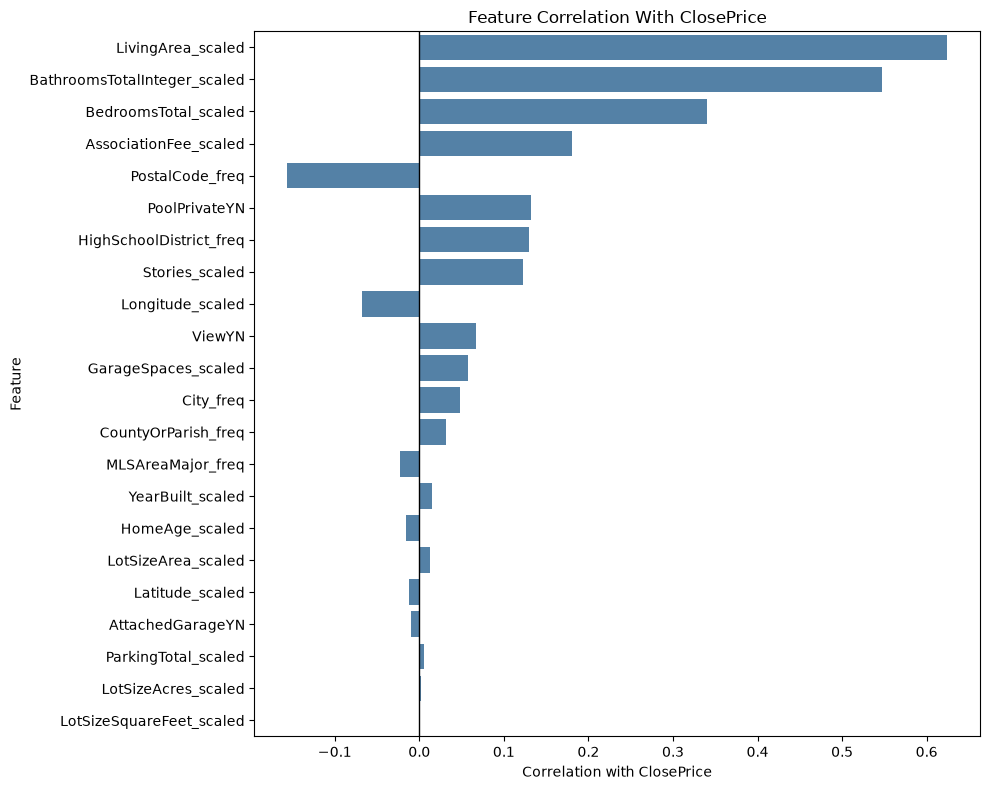

LivingArea_scaled               0.624
BathroomsTotalInteger_scaled    0.547
BedroomsTotal_scaled            0.340
AssociationFee_scaled           0.181
PostalCode_freq                -0.156
PoolPrivateYN                   0.133
HighSchoolDistrict_freq         0.130
Stories_scaled                  0.122
Longitude_scaled               -0.068
ViewYN                          0.067
GarageSpaces_scaled             0.057
City_freq                       0.048
CountyOrParish_freq             0.032
MLSAreaMajor_freq              -0.023
YearBuilt_scaled                0.015
HomeAge_scaled                 -0.015
LotSizeArea_scaled              0.012
Latitude_scaled                -0.012
AttachedGarageYN               -0.010
ParkingTotal_scaled             0.005
LotSizeAcres_scaled             0.002
LotSizeSquareFeet_scaled        0.001
Name: ClosePrice, dtype: float64

In [46]:
plot_corr = close_price_corr.sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=plot_corr.values,
    y=plot_corr.index,
    color="steelblue",
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with ClosePrice")
plt.ylabel("Feature")
plt.title("Feature Correlation With ClosePrice")
plt.tight_layout()
plt.show()

plot_corr.round(3)


In [47]:
X_train_3 = train[sig_mag_price_corr_features]
y_train_3 = train[target]

significant_model = LinearRegression()
significant_model.fit(X_train_3, y_train_3)

def evaluate_split_with_features(model, split_name, split_df, selected_features):
    X = split_df[selected_features]
    y = split_df[target]
    predictions = model.predict(X)

    return {
        "model": "LinearRegression",
        "target": target,
        "split": split_name,
        "rows": len(split_df),
        "r2_close_price": r2_score(y, predictions),
        "mae_close_price": mean_absolute_error(y, predictions),
        "rmse_close_price": float(np.sqrt(mean_squared_error(y, predictions))),
    }
bigger_than_03_results = pd.DataFrame([
    evaluate_split_with_features(significant_model, "train", train, sig_mag_price_corr_features),
    evaluate_split_with_features(significant_model, "validation", validation, sig_mag_price_corr_features),
    evaluate_split_with_features(significant_model, "test", test, sig_mag_price_corr_features),
])

bigger_than_03_results



,model,target,split,rows,r2_close_price,mae_close_price,rmse_close_price
0,LinearRegression,ClosePrice,train,140956,0.478323,504336.709533,867874.005901
1,LinearRegression,ClosePrice,validation,26475,0.475880,503202.430688,900226.942635
2,LinearRegression,ClosePrice,test,35193,0.477280,522926.717876,906219.969144


In [48]:
baseline_results

,model,target,split,rows,r2_close_price,mae_close_price,rmse_close_price
0,LinearRegression,ClosePrice,train,140956,0.499931,479200.484688,849709.902382
1,LinearRegression,ClosePrice,validation,26475,0.499136,478109.919459,880027.974047
2,LinearRegression,ClosePrice,test,35193,0.507638,492991.207051,879510.390343


## Alternative Time-Split Baselines

To compare shorter validation/test windows while keeping the same approximate 4:1:1 month ratio, train two additional Linear Regression baselines:

- **8/2/2 split:** train Jun 2025-Jan 2026, validate Feb-Mar 2026, test Apr-May 2026.
- **4/1/1 split:** train Dec 2025-Mar 2026, validate Apr 2026, test May 2026.


In [49]:
def train_and_evaluate_scenario(scenario_name: str, train_months: list[str], validation_months: list[str], test_months: list[str]) -> list[dict]:
    scenario_train = df[df["close_month"].isin(train_months)].copy()
    scenario_validation = df[df["close_month"].isin(validation_months)].copy()
    scenario_test = df[df["close_month"].isin(test_months)].copy()

    model = LinearRegression()
    model.fit(scenario_train[feature_cols], scenario_train[target])

    rows = []
    for split_name, split_df, months in [
        ("train", scenario_train, train_months),
        ("validation", scenario_validation, validation_months),
        ("test", scenario_test, test_months),
    ]:
        predictions = model.predict(split_df[feature_cols])
        y = split_df[target]
        rows.append({
            "scenario": scenario_name,
            "model": "LinearRegression",
            "target": target,
            "split": split_name,
            "months": ",".join(months),
            "rows": len(split_df),
            "r2_close_price": r2_score(y, predictions),
            "mae_close_price": mean_absolute_error(y, predictions),
            "rmse_close_price": float(np.sqrt(mean_squared_error(y, predictions))),
        })

    return rows


split_scenarios = [
    (
        "13_train_3_val_3_test",
        ["2024-11", "2024-12", "2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09", "2025-10", "2025-11"],
        ["2025-12", "2026-01", "2026-02"],
        ["2026-03", "2026-04", "2026-05"],
    ),
    (
        "8_train_2_val_2_test",
        ["2025-06", "2025-07", "2025-08", "2025-09", "2025-10", "2025-11", "2025-12", "2026-01"],
        ["2026-02", "2026-03"],
        ["2026-04", "2026-05"],
    ),
    (
        "4_train_1_val_1_test",
        ["2025-12", "2026-01", "2026-02", "2026-03"],
        ["2026-04"],
        ["2026-05"],
    ),
]

split_comparison_rows = []
for scenario in split_scenarios:
    split_comparison_rows.extend(train_and_evaluate_scenario(*scenario))

split_comparison_results = pd.DataFrame(split_comparison_rows)
split_comparison_results.to_csv(SPLIT_RESULTS_FILE, index=False)
split_comparison_results


,scenario,model,target,split,months,rows,r2_close_price,mae_close_price,rmse_close_price
0,13_train_3_val_3_test,LinearRegression,ClosePrice,train,"2024-11,2024-12,2025-01,2025-02,2025-03,2025-0...",140956,0.499931,479200.484688,849709.902382
1,13_train_3_val_3_test,LinearRegression,ClosePrice,validation,"2025-12,2026-01,2026-02",26475,0.499136,478109.919459,880027.974047
2,13_train_3_val_3_test,LinearRegression,ClosePrice,test,"2026-03,2026-04,2026-05",35193,0.507638,492991.207051,879510.390343
3,8_train_2_val_2_test,LinearRegression,ClosePrice,train,"2025-06,2025-07,2025-08,2025-09,2025-10,2025-1...",86362,0.505575,475925.749394,852357.379796
4,8_train_2_val_2_test,LinearRegression,ClosePrice,validation,"2026-02,2026-03",19710,0.498619,485415.265794,879932.989133
5,8_train_2_val_2_test,LinearRegression,ClosePrice,test,"2026-04,2026-05",24027,0.516543,494738.946158,868612.831502
6,4_train_1_val_1_test,LinearRegression,ClosePrice,train,"2025-12,2026-01,2026-02,2026-03",37641,0.505371,481099.074609,878564.101858
7,4_train_1_val_1_test,LinearRegression,ClosePrice,validation,2026-04,12014,0.493212,503250.182925,912769.897437
8,4_train_1_val_1_test,LinearRegression,ClosePrice,test,2026-05,12013,0.444319,495377.747126,905999.538268


In [50]:
test_split_results = split_comparison_results[split_comparison_results["split"] == "test"].copy()
test_split_results[["scenario", "rows", "r2_close_price", "mae_close_price", "rmse_close_price"]].sort_values("r2_close_price", ascending=False)


,scenario,rows,r2_close_price,mae_close_price,rmse_close_price
5,8_train_2_val_2_test,24027,0.516543,494738.946158,868612.831502
2,13_train_3_val_3_test,35193,0.507638,492991.207051,879510.390343
8,4_train_1_val_1_test,12013,0.444319,495377.747126,905999.538268


Current run summary: the 8/2/2 split produced the highest test R² among these three Linear Regression baselines, while the 4/1/1 split had the weakest test R².


Baseline result from the current run: the Linear Regression model achieved approximately **0.508 R²** on the chronological test set.